<a href="https://colab.research.google.com/github/win-eva/als-sex-stratified-target-discovery/blob/main/01_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd
import numpy as np
import time
import requests
from itertools import combinations
import matplotlib.pyplot as plt

In [2]:
drive.mount("/content/drive")

Mounted at /content/drive


## Gene ID annotation

The raw AnswerALS matrix only has Ensembl gene IDs, no symbol, biotype or description.
Pulling these from the Ensembl REST API once and saving an annotated copy (biotype is needed later for the protein-coding filter).

Only run this section if `AnswerALS_raw_counts_annotated.csv` doesn't exist yet.

In [9]:
path = "/content/drive/MyDrive/ALS Data/AnswerALS-1276-T-v1-release7_raw-counts.csv"
counts = pd.read_csv(path)
counts.shape

(60664, 1277)

In [12]:
def ensembl_lookup_batch(ids, max_retries=3):
    url = "https://rest.ensembl.org/lookup/id"
    headers = {"Content-Type": "application/json", "Accept": "application/json"}

    data = {}
    for attempt in range(max_retries):
        try:
            r = requests.post(url, headers=headers, json={"ids": ids}, timeout=30)
            if r.status_code == 429:
                time.sleep(int(r.headers.get("Retry-After", 5)))
                continue
            r.raise_for_status()
            data = r.json()
            break
        except requests.exceptions.RequestException as e:
            print(f"batch failed (attempt {attempt+1}): {e}")
            time.sleep(3 * (attempt + 1))

    rows = []
    for ensg in ids:
        info = data.get(ensg)
        if info is None:
            rows.append({"Geneid": ensg, "symbol": None, "biotype": None, "description": None})
        else:
            rows.append({
                "Geneid": ensg,
                "symbol": info.get("display_name"),
                "biotype": info.get("biotype"),
                "description": info.get("description")
            })
    return pd.DataFrame(rows)

In [13]:
gene_ids = counts["Geneid"].astype(str).unique().tolist()
chunk_size = 500
all_chunks = []

# saving every so often since this dies on connection loss otherwise and I don't want to redo 100+ requests
for i in range(0, len(gene_ids), chunk_size):
    chunk = gene_ids[i:i + chunk_size]
    all_chunks.append(ensembl_lookup_batch(chunk))
    time.sleep(0.2)

    if (i // chunk_size) % 20 == 0:
        pd.concat(all_chunks, ignore_index=True).to_csv("/content/drive/MyDrive/ALS Data/gene_annotation_partial.csv", index=False)
        print(i + chunk_size, "/", len(gene_ids))

gene_annotation = pd.concat(all_chunks, ignore_index=True)
gene_annotation["biotype"].value_counts().head()

500 / 60664
10500 / 60664
20500 / 60664
30500 / 60664
40500 / 60664
50500 / 60664
60500 / 60664


,count
biotype,
protein_coding,19980
lncRNA,15783
processed_pseudogene,9479
misc_RNA,2215
unprocessed_pseudogene,1933


In [15]:
counts_annot = counts.merge(gene_annotation, on="Geneid", how="left")

front = ["Geneid", "symbol", "biotype", "description"]
counts_annot = counts_annot[front + [c for c in counts_annot.columns if c not in front]]

out_path = "/content/drive/MyDrive/ALS Data/AnswerALS_raw_counts_annotated.csv"
counts_annot.to_csv(out_path, index=False)

## Dataset overview

In [16]:
path = "/content/drive/MyDrive/ALS Data/AnswerALS_raw_counts_annotated.csv"
counts = pd.read_csv(path)

annotation_cols = ["Geneid", "symbol", "biotype", "description"]
sample_cols = [c for c in counts.columns if c not in annotation_cols]

case_samples = [c for c in sample_cols if c.startswith("CASE")]
ctrl_samples = [c for c in sample_cols if c.startswith("CTRL")]

total_genes = counts.shape[0]
total_samples = len(sample_cols)

total_genes, total_samples, len(case_samples), len(ctrl_samples)

(60664, 1276, 797, 479)

## Donor distribution

Sample IDs encode diagnosis and donor (`CASE-<donor>-...` / `CTRL-<donor>-...`), so
donor-level counts can be pulled straight from the column names.

In [17]:
meta = pd.DataFrame({
    "sample_id": sample_cols,
    "diagnosis": [c.split("-")[0] for c in sample_cols],
    "donor_id": [c.split("-")[1] for c in sample_cols]
})

samples_per_donor = meta.groupby("donor_id").size()
donor_counts = samples_per_donor.value_counts().sort_index()
donor_counts

,count
1,1075
2,27
147,1


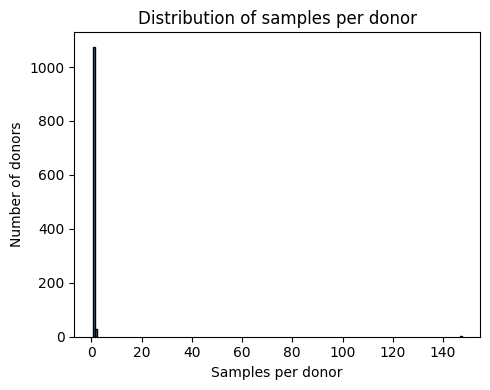

In [18]:
plt.figure(figsize=(5, 4))
plt.bar(donor_counts.index, donor_counts.values, width=0.8, edgecolor="black")
plt.xlabel("Samples per donor")
plt.ylabel("Number of donors")
plt.title("Distribution of samples per donor")
plt.tight_layout()
plt.show()

## Intra-donor correlation

A handful of donors contributed more than one sample, and one donor contributed 147.
Multiple samples from the same donor aren't independent, so before collapsing down to
one representative sample per donor it's worth checking that repeat samples actually
resemble each other.

In [19]:
X_log = np.log1p(counts[sample_cols])

def within_donor_correlations(X_log, meta):
    corrs = []
    for donor, group in meta.groupby("donor_id"):
        samples = group["sample_id"].tolist()
        if len(samples) < 2:
            continue
        sub = X_log[samples]
        for s1, s2 in combinations(samples, 2):
            corrs.append(sub[s1].corr(sub[s2]))
    return np.array(corrs)

within_corr = within_donor_correlations(X_log, meta)
within_corr.min(), within_corr.mean(), within_corr.max()

(np.float64(0.9519801549649338),
 np.float64(0.9829221825339995),
 np.float64(0.9915098161496727))